In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#pd.set_option('display.max_rows', None)
#pd.set_option('display.float_format', lambda x: '%.3f' % x)



In [97]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [98]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [100]:
df2 = df.drop(["area_type","availability","society","balcony"],axis = 1)
df2

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [101]:
df2.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [102]:
df3= df2.dropna()

In [103]:
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [104]:
df3['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [105]:
df3['bhk'] = df3['size'].apply(lambda x : int(x.split(' ')[0]))

In [106]:
df3.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [107]:
df3['bhk'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [108]:
df3[df3['bhk']>20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [109]:
df3['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2067,), dtype=object)

In [110]:
def isfloat(x):
    try:
        float(x)
    except:
        return False
    return True

In [111]:
df3[~df3['total_sqft'].apply(isfloat)]

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
...,...,...,...,...,...,...
12975,Whitefield,2 BHK,850 - 1060,2.0,38.190,2
12990,Talaghattapura,3 BHK,1804 - 2273,3.0,122.000,3
13059,Harlur,2 BHK,1200 - 1470,2.0,72.760,2
13265,Hoodi,2 BHK,1133 - 1384,2.0,59.135,2


In [112]:
df4 = df3.copy()

In [113]:
def change_sqft(x):
    nums = x.split('-')
    if len(nums) == 2:
        return (float(nums[0])+float(nums[1]))/2
    try:
        return float(x)
    except:
        return None

In [114]:
change_sqft('2002 - 2009')


2005.5

In [115]:
df4['total_sqft']= df4['total_sqft'].apply(change_sqft)
df4.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [173]:
df5 = df4.copy()
df5['price_per_sqft'] = df5['price']*100000/df5['total_sqft']
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [174]:
len(df5.location.unique())

1304

In [175]:
df5.location = df5.location.apply(lambda x : x.strip())
location_stats = df5.groupby('location')['location'].agg('count').sort_values(ascending = False)
location_stats

location
Whitefield                            535
Sarjapur  Road                        392
Electronic City                       304
Kanakpura Road                        266
Thanisandra                           236
                                     ... 
poornaprajna layout                     1
pavitra paradise                        1
near Ramanashree California resort      1
mvj engineering college                 1
1Kasavanhalli                           1
Name: location, Length: 1293, dtype: int64

In [176]:
len(location_stats[location_stats<=10])

1052

In [177]:
location_stats_lessthan10 = location_stats[location_stats<=10]
location_stats_lessthan10

location
Kalkere                               10
Sadashiva Nagar                       10
BTM 1st Stage                         10
Basapura                              10
Gunjur Palya                          10
                                      ..
poornaprajna layout                    1
pavitra paradise                       1
near Ramanashree California resort     1
mvj engineering college                1
1Kasavanhalli                          1
Name: location, Length: 1052, dtype: int64

In [178]:
len(df5.location.unique())

1293

In [179]:
df5['location'] = df5['location'].apply(lambda x : 'other' if x in location_stats_lessthan10 else x)
len(df5.location.unique())

242

In [180]:
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [28]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13200 non-null  object 
 1   size            13200 non-null  object 
 2   total_sqft      13200 non-null  float64
 3   bath            13200 non-null  float64
 4   price           13200 non-null  float64
 5   BHK             13200 non-null  int64  
 6   price_per_sqft  13200 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 825.0+ KB


In [181]:
# Removing outliers
#first the minimum room size should be 300 sqft
df5[df5['total_sqft']/df5['bhk']<300].head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,other,3 Bedroom,500.0,3.0,100.0,3,20000.000000


In [182]:
df6 = df5[~(df5['total_sqft']/df5['bhk']<300)]

In [183]:
df6.shape

(12502, 7)

In [185]:
df6.price_per_sqft.describe()

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [186]:
# removing outlier using (mean -+3*std)
#Price_per_sqrt
def reduce_pps(df):
    df_out = pd.DataFrame()
    for key,subdf in df.groupby('location'):
        m = np.mean(subdf['price_per_sqft'])
        st = np.std(subdf['price_per_sqft'])
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out,reduced_df],ignore_index = True)
    return df_out
df7 = reduce_pps(df6)
df7.shape

(10241, 7)

In [187]:
df6.shape

(12502, 7)

In [188]:
# now there are some properties which at same location, 3bhk has less price than 2bhk
# to detect such outliers
def plot_scatter(df,location):
    bhk2 = df[(df['location'] == location) & (df.bhk == 2)]
    bhk3 = df[(df['location'] == location) & (df.bhk == 3)]
    plt.figure(figsize = (15,10))
    plt.scatter(bhk2.total_sqft,bhk2.price,color = 'red',label = '2bhk',s = 50)
    plt.scatter(bhk3.total_sqft,bhk3.price,marker= '+',color = 'blue',label = '3bhk',s = 50)
    plt.xlabel("Total Square Fit Area")
    plt.ylabel("Price")
    plt.title(location)
    plt.legend()
    plt.show()
    

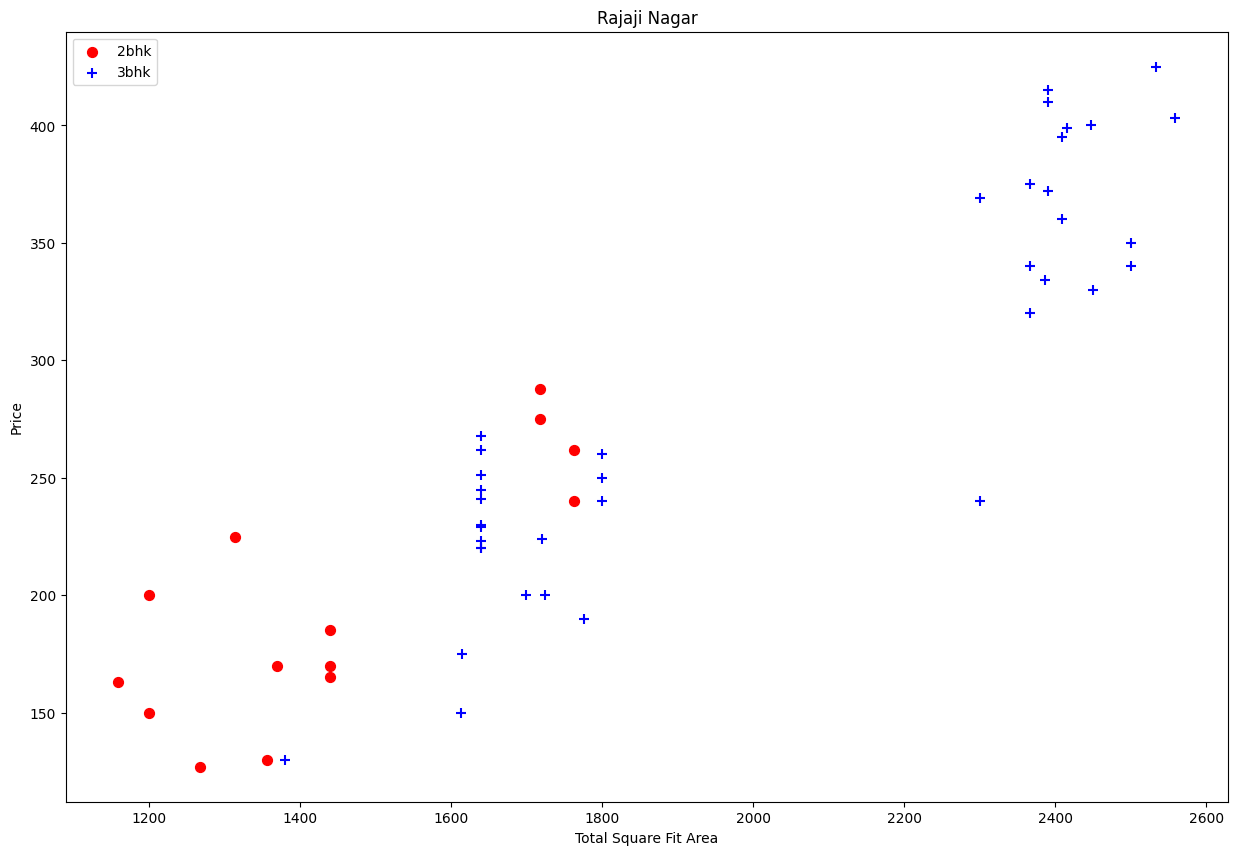

In [189]:
plot_scatter(df7,"Rajaji Nagar")

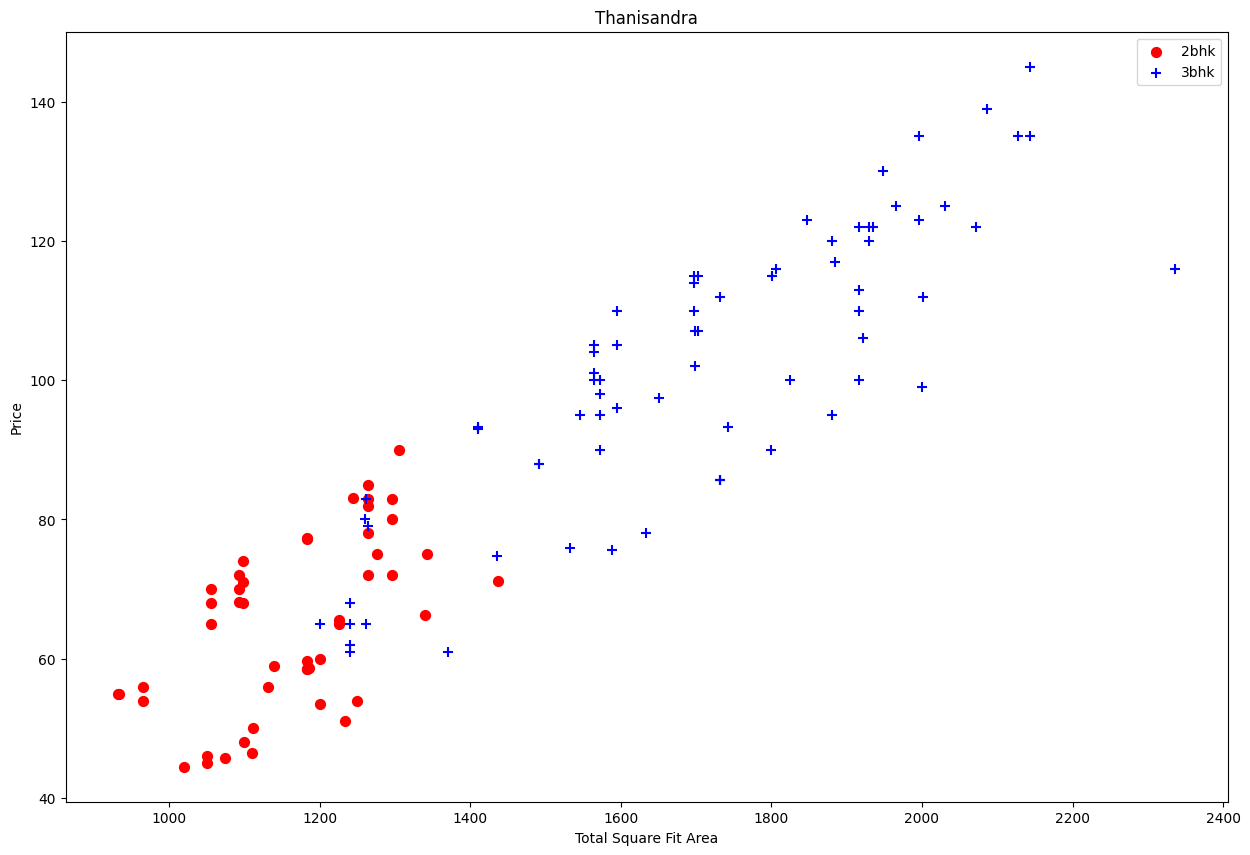

In [190]:
plot_scatter(df7,"Thanisandra")

In [39]:
# for each location and then its bhk we will create dictionaries such as 
# 1{
#     mean :
#     std:
#     count:
# },
# 2{}

# then we can remove the 2bhk

In [191]:
def remove_outliers_bhk(df):
    reduce_index = np.array([])
    for loc,loc_df in df.groupby('location'):
        bhk_stats = {}
        for bhk,bhk_df in loc_df.groupby('bhk'):
            bhk_stats[bhk] = {'mean' : np.mean(bhk_df.price_per_sqft),
                     'std' : np.std(bhk_df.price_per_sqft),
                    'counts' : bhk_df.shape[0]
                           }
        for bhk,bhk_df in loc_df.groupby('bhk'):
            stats = bhk_stats.get(bhk -1)
            if stats and stats['counts']>5:
                reduce_index = np.append(reduce_index,bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
                
    return df.drop(reduce_index,axis = 'index')
df8 = remove_outliers_bhk(df7)

In [192]:
df8.shape

(7329, 7)

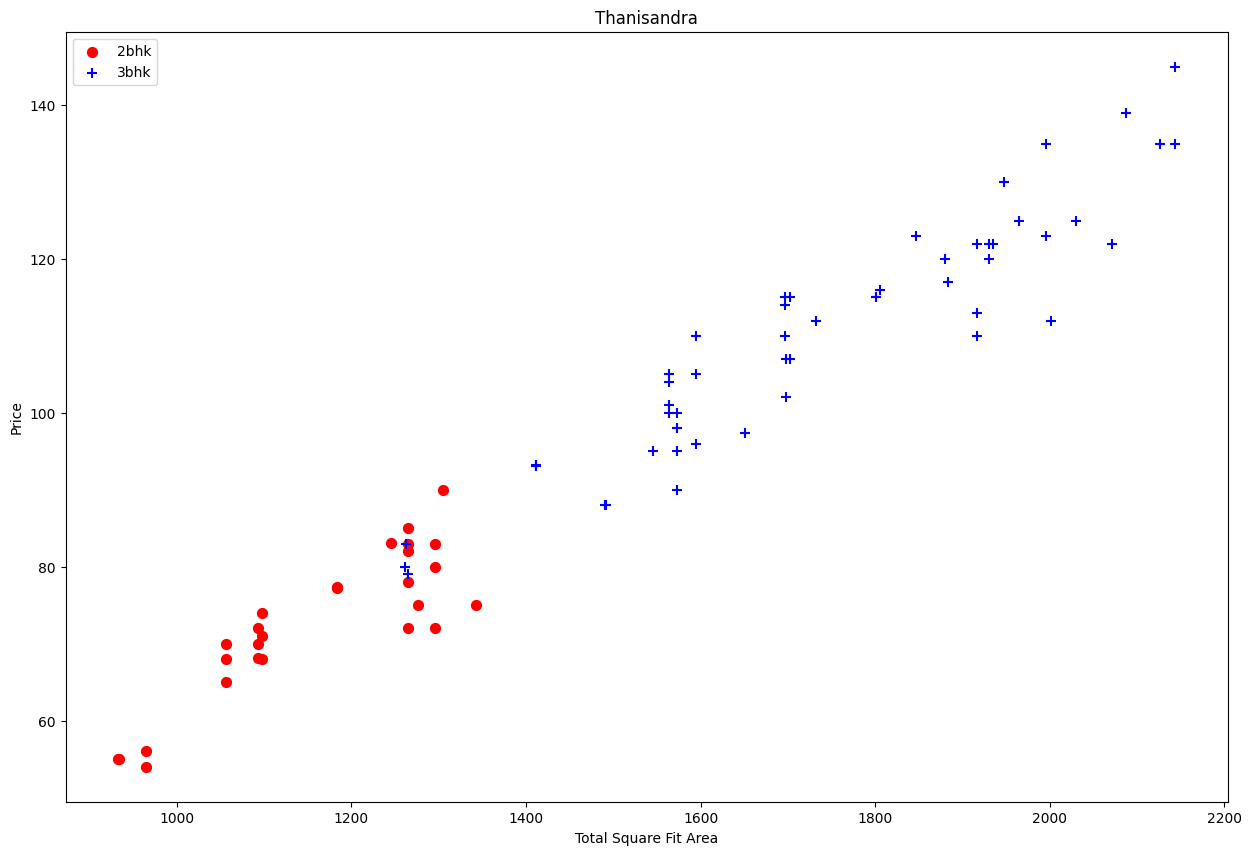

In [42]:
plot_scatter(df8,"Thanisandra")

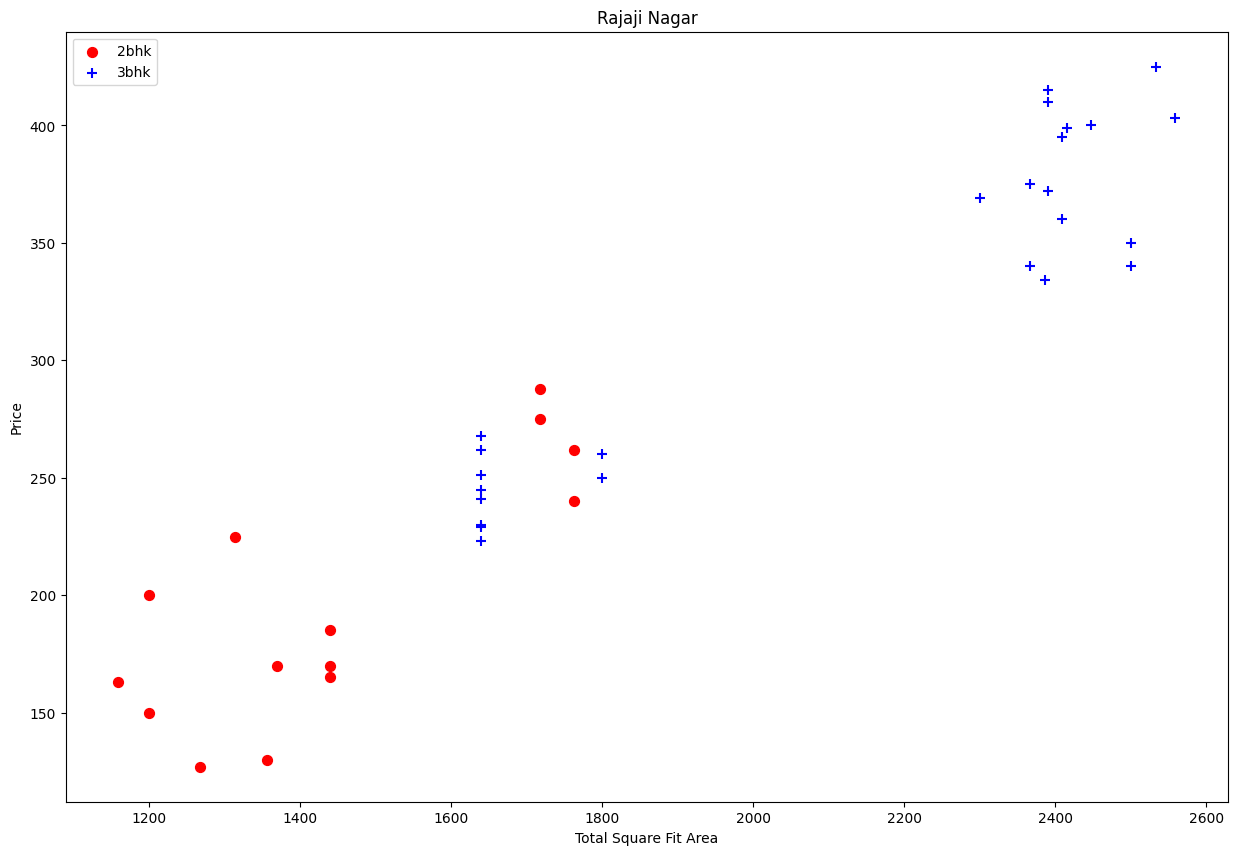

In [43]:
plot_scatter(df8,"Rajaji Nagar")

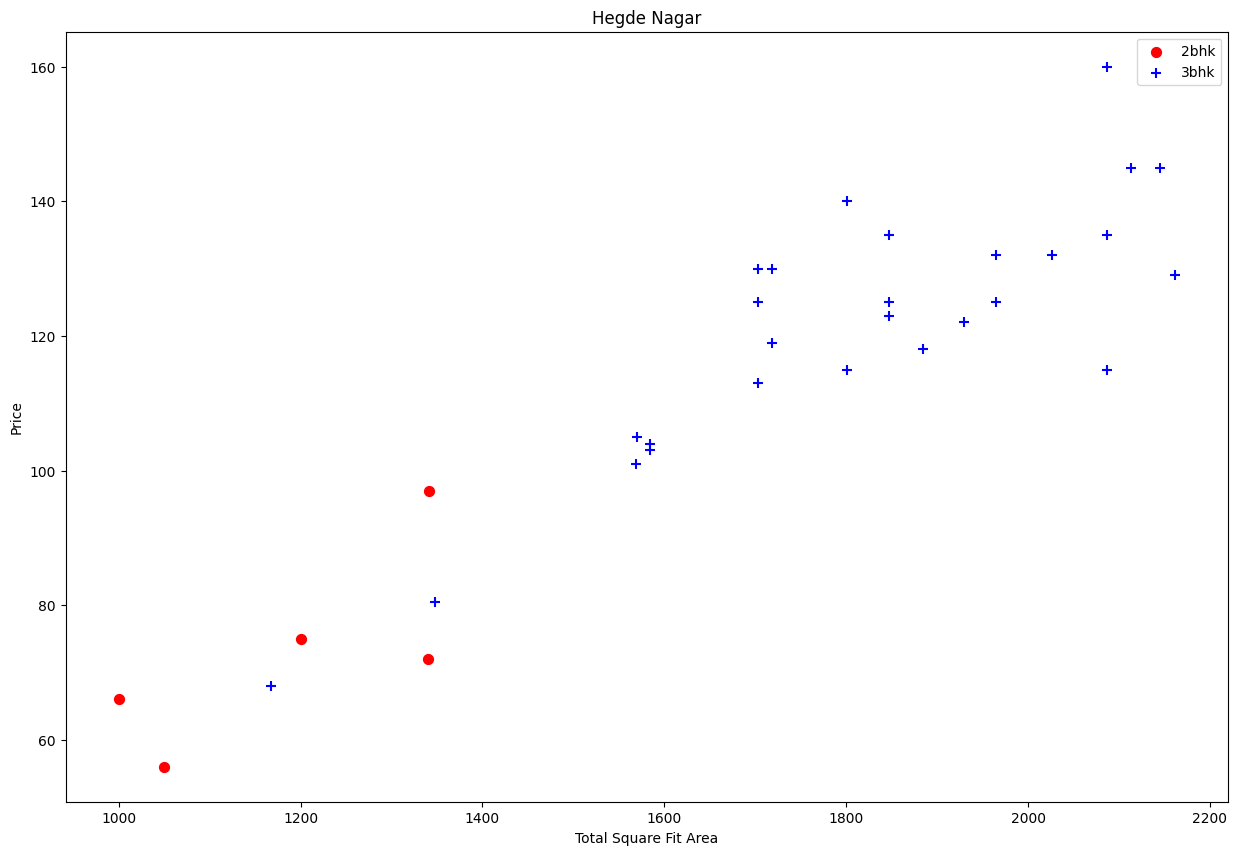

In [44]:
plot_scatter(df8,"Hegde Nagar")

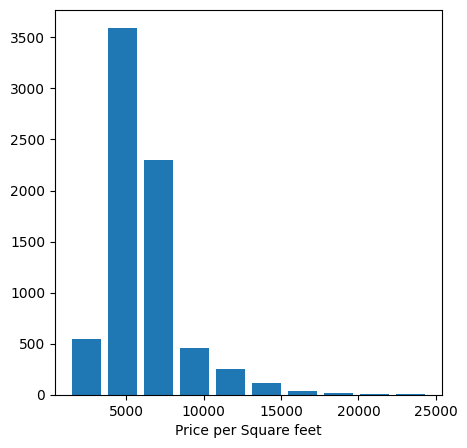

In [193]:
plt.figure(figsize = (5,5))
#bins = np.arange(0, max(df8.price_per_sqft) + 5000, 5000)
plt.hist(df8.price_per_sqft,rwidth=0.8)
plt.xlabel('Price per Square feet')
plt.show()

In [194]:
df8[df8.bath>10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5277,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
8486,other,10 BHK,12000.0,12.0,525.0,10,4375.000000
8575,other,16 BHK,10000.0,16.0,550.0,16,5500.000000
9308,other,11 BHK,6000.0,12.0,150.0,11,2500.000000
9639,other,13 BHK,5425.0,13.0,275.0,13,5069.124424


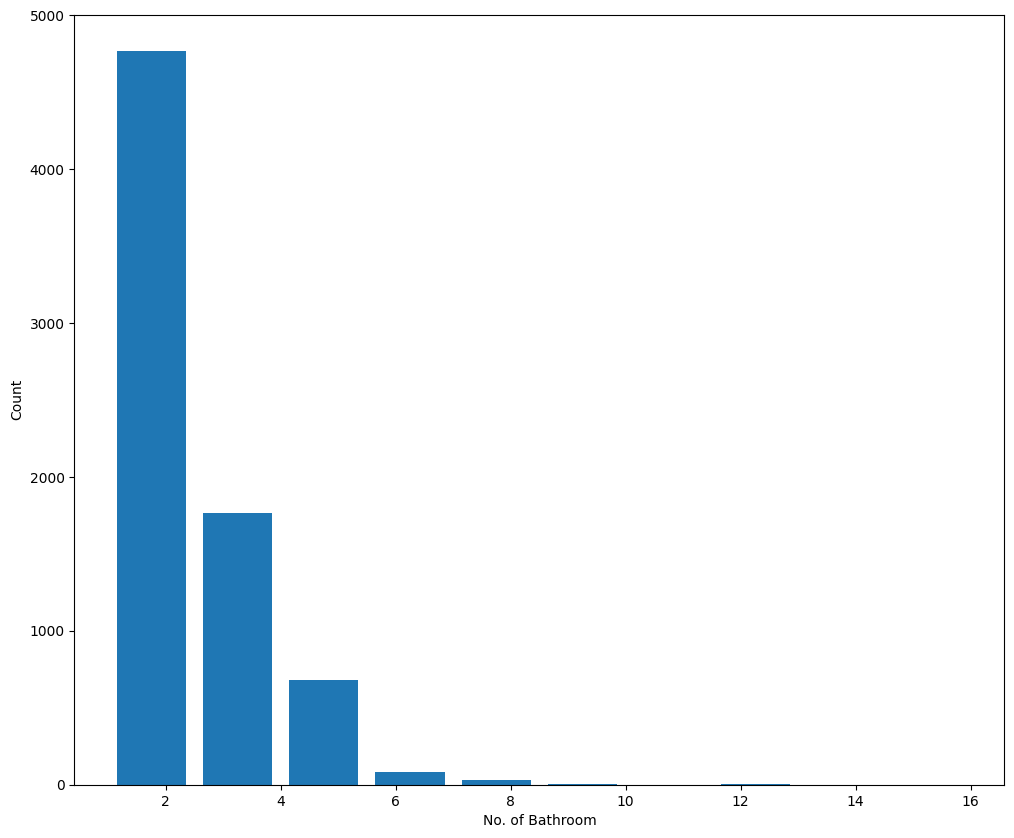

In [195]:
plt.figure(figsize = (12,10))
plt.hist(df8.bath,rwidth = 0.8)
plt.xlabel("No. of Bathroom")
plt.ylabel("Count")
plt.show()

In [196]:
df8[df8.bath>df8.bhk+2]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
1626,Chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.032520
5238,Nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.571429
6711,Thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.034330
8411,other,6 BHK,11338.0,9.0,1000.0,6,8819.897689


In [197]:
df9 = df8[df8.bath<df8.bhk+2]
df9.shape

(7251, 7)

In [198]:
df10 = df9.drop(['size','price_per_sqft'],axis = 1)
df10.head(3)

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3


In [199]:

df10['location'].value_counts()

location
other                    1134
Whitefield                238
Sarjapur  Road            186
Electronic City           162
Raja Rajeshwari Nagar     140
                         ... 
Nagasandra                  4
Vishwapriya Layout          4
Thyagaraja Nagar            4
Vishveshwarya Layout        4
Marsur                      3
Name: count, Length: 242, dtype: int64

In [200]:
dummies = pd.get_dummies(df10.location).astype(int)
dummies.head(5)

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [201]:
df11 = pd.concat([df10,dummies.drop('other',axis = 1)],axis = 1)
df11.head()

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1st Block Jayanagar,1630.0,3.0,194.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1st Block Jayanagar,1875.0,2.0,235.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1st Block Jayanagar,1200.0,2.0,130.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1st Block Jayanagar,1235.0,2.0,148.0,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [202]:
df12 = df11.drop('location',axis = 1)

In [203]:
df12.shape

(7251, 245)

In [204]:
# Splitting X and Y
X = df12.drop('price',axis = 1)
y = df12.price

In [205]:
X.head()

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [206]:
y.head()

0    428.0
1    194.0
2    235.0
3    130.0
4    148.0
Name: price, dtype: float64

In [207]:
# Trainning- testing split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 10)

In [208]:
# Linear model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
lr.score(X_test,y_test)


0.8452277697874346

In [209]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
cv = ShuffleSplit(n_splits=5,test_size=0.2,random_state = 10)
cross_val_score(LinearRegression(),X,y,cv = cv)

array([0.84522777, 0.80004632, 0.88682995, 0.842265  , 0.86250633])

In [210]:
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
def find_best_model_using_gridsearchcv(X,y):
    algos = {
        'linear_reg':{
            'model': LinearRegression(),
            'params':{
                'fit_intercept':[True,False]
            }
        },
        'lasso':{
            'model': Lasso(),
        'params': {
            'alpha':[1,0.1,0.001,10,2],
            'selection':['random','cyclic']
        }
        },
        'decision_tree':{
            'model': DecisionTreeRegressor(),
            'params':{
                'criterion':['squared_error','friedman_mse'],
                'splitter':['best','random']
            }
        
        }
    }
    score = []
    cv = ShuffleSplit(n_splits= 5,
                      test_size = 0.2,
                      random_state = 0)
    
    for algo_name,config in algos.items():
        gs = GridSearchCV(config['model'],
                          config['params'],
                          cv=cv,
                          return_train_score=False)
        gs.fit(X,y)
        score.append({
            'model':algo_name,
            'best_score':gs.best_score_,
            'best_param': gs.best_params_
        })
    return pd.DataFrame(score,columns = ['model','best_score','best_param'])

find_best_model_using_gridsearchcv(X,y)

,model,best_score,best_param
0,linear_reg,0.819001,{'fit_intercept': False}
1,lasso,0.818335,"{'alpha': 0.001, 'selection': 'cyclic'}"
2,decision_tree,0.743952,"{'criterion': 'squared_error', 'splitter': 'ra..."


In [211]:

def predict_price(location,sqft,bath,bhk):
    loc_index = np.where(X.columns == location)[0][0]
    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    if loc_index >= 0 :
        x[loc_index] =1
    return lr.predict([x])[0]

In [218]:
predict_price("1st Phase JP Nagar",1000,2,2)

np.float64(83.49904677194222)

In [219]:
predict_price("1st Phase JP Nagar",1000,3,3)

np.float64(86.80519395220932)

In [220]:
predict_price("Indira Nagar",1000,2,2)

np.float64(181.278154840066)

In [221]:
predict_price("Indira Nagar",1000,3,3)

np.float64(184.5843020203331)

In [223]:
import pickle
with open("banglore_home_price_model.pickle",'wb') as f:
    pickle.dump(lr,f)

In [225]:
import json
columns = {
    'data_columns' : [col.lower() for col in X.columns]
}

with open("Columns.json","w") as f:
    f.write(json.dumps(columns))